## STELLAR Installation

In [10]:
!git clone -q https://github.com/microsoft/STELLAR.git
!ls -la /kaggle/working/STELLAR
%cd /kaggle/working/STELLAR

total 88
drwxr-xr-x  9 root root  4096 Sep 20 09:25 .
drwxr-xr-x  4 root root  4096 Sep 20 09:18 ..
drwxr-xr-x 10 root root  4096 Sep 20 09:18 configs
drwxr-xr-x  2 root root  4096 Sep 20 09:18 docs
drwxr-xr-x  2 root root  4096 Sep 20 09:18 examples
drwxr-xr-x  8 root root  4096 Sep 20 09:18 .git
-rw-r--r--  1 root root   136 Sep 20 09:18 .gitignore
drwxr-xr-x  2 root root  4096 Sep 20 09:18 images
-rw-r--r--  1 root root  1066 Sep 20 09:18 LICENSE
-rw-r--r--  1 root root  3409 Sep 20 09:18 load_stellar.py
-rw-r--r--  1 root root 20014 Sep 20 09:18 README.md
-rw-r--r--  1 root root    72 Sep 20 09:18 requirements-eval.txt
-rw-r--r--  1 root root   139 Sep 20 09:18 requirements-inference.txt
-rw-r--r--  1 root root   566 Sep 20 09:18 requirements.txt
-rw-r--r--  1 root root  1329 Sep 20 09:18 run.py
-rw-r--r--  1 root root   542 Sep 20 09:18 SECURITY.md
drwxr-xr-x  8 root root  4096 Sep 20 09:19 src
drwxr-xr-x  8 root root  4096 Sep 20 09:25 STELLAR
/kaggle/working/STELLAR


In [12]:
# Installing requirments.txt for STELLAR 
!pip install -q -r requirements.txt

  Preparing metadata (setup.py) ... done
ERROR: Ignored the following versions that require a different python version: 0.0.0 Requires-Python <3.11,>=3.8; 0.0.10 Requires-Python >=3.8,<3.9; 0.0.11 Requires-Python >=3.8,<3.9; 0.0.12 Requires-Python >=3.8,<3.9; 0.0.14 Requires-Python >=3.8,<3.9; 0.0.15 Requires-Python >=3.8,<3.9; 0.0.16 Requires-Python >=3.8,<3.9; 0.0.17 Requires-Python >=3.8,<3.9; 0.0.18 Requires-Python >=3.8,<3.9; 0.0.19 Requires-Python >=3.8,<3.9; 0.0.20 Requires-Python >=3.8,<3.9; 0.0.21 Requires-Python >=3.8,<3.9; 0.0.22 Requires-Python >=3.8,<3.9; 0.0.23 Requires-Python >=3.8,<3.9; 0.0.24 Requires-Python >=3.8,<3.9; 0.0.25 Requires-Python >=3.8,<3.9; 0.0.26 Requires-Python >=3.8,<3.9; 0.0.27 Requires-Python >=3.8,<3.9; 0.0.28 Requires-Python >=3.8,<3.9; 0.0.29 Requires-Python >=3.8,<3.9; 0.0.30 Requires-Python >=3.8,<3.9; 0.0.31 Requires-Python >=3.8,<3.9; 0.0.32 Requires-Python >=3.8,<3.9; 0.0.33 Requires-Python >=3.8,<3.9; 0.0.34 Requires-Python >=3.8,<3.9; 0.0.3

In [13]:
# Installing safetensors for huggingface_hub for STELLAR working
!pip install -q huggingface_hub safetensors

In [14]:
# Loading baseline STELLAR
import json
import torch
from huggingface_hub import hf_hub_download
from safetensors.torch import load_file
from src.models.stellar_model import STELLARModel # Loading the STELLAR-B16 model

repo = "microsoft/STELLAR" # STELLAR path
config_path = hf_hub_download(repo_id=repo,filename="config.json") # Configuration path

with open(config_path, "r") as f:
    config = json.load(f)
cfg = config["models"]["stellar-b16"] # Loading STELLAR-B16 model (more efficient)

# Loading model with configuration
model = STELLARModel(
    num_sparse_tokens=cfg["num_sparse_tokens"],
    num_decoder_layers=cfg["num_decoder_layers"],
    spatial_temp=cfg["spatial_temp"],
    vit_pretrained=cfg["backbone"],
    do_recon=False,
    do_clustering=False,
    vq_model=None,
)

# Setting up device for evaluation
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
model.eval()

You are using a model of type vit_mae to instantiate a model of type vit. This is not supported for all configurations of models and can yield errors.


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTModel LOAD REPORT from: facebook/vit-mae-base
Key                                                                              | Status     | 
---------------------------------------------------------------------------------+------------+-
decoder.decoder_layers.{0, 1, 2, 3, 4, 5, 6, 7}.intermediate.dense.bias          | UNEXPECTED | 
decoder.decoder_layers.{0, 1, 2, 3, 4, 5, 6, 7}.attention.attention.query.bias   | UNEXPECTED | 
decoder.decoder_layers.{0, 1, 2, 3, 4, 5, 6, 7}.attention.attention.key.bias     | UNEXPECTED | 
decoder.decoder_layers.{0, 1, 2, 3, 4, 5, 6, 7}.layernorm_after.bias             | UNEXPECTED | 
decoder.decoder_layers.{0, 1, 2, 3, 4, 5, 6, 7}.attention.output.dense.weight    | UNEXPECTED | 
decoder.decoder_layers.{0, 1, 2, 3, 4, 5, 6, 7}.intermediate.dense.weight        | UNEXPECTED | 
decoder.decoder_layers.{0, 1, 2, 3, 4, 5, 6, 7}.attention.attention.query.weight | UNEXPECTED | 
decoder.decoder_layers.{0, 1, 2, 3, 4, 5, 6, 7}.layernorm_before.bias         

STELLARModel(
  (encoder): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ViTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViTLayer(
          (attention): ViTAttention(
            (attention): ViTSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
            )
            (output): ViTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ViTIntermediate(
            (dense): Linear(in_features=768, out_features=3072, bias=True)
            (intermediate_act_

In [15]:
"""
Sanity test on STELLAR-B16 to check semantic and localization matrix

For device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
"""
image = torch.rand(1, 3, 224, 224,device=device)
with torch.no_grad():
    out = model.encode(image)

for key, value in out.items():
    if torch.is_tensor(value):
        print(key, value.shape)
"""
sparse torch.Size([]) is semantic matrix
spatial torch.Size([]) is localization matrix
"""

sparse torch.Size([1, 16, 768])
spatial torch.Size([1, 196, 16])
concat torch.Size([1, 16, 964])
lowrank torch.Size([1, 196, 768])
dense torch.Size([1, 196, 768])
cls torch.Size([1, 1, 768])
peak_dist torch.Size([1, 16])


'\nsparse torch.Size([]) is semantic matrix\nspatial torch.Size([]) is localization matrix\n'

## GlasSegmentationDataset

In [16]:
import os
import numpy as np
import torch

from PIL import Image
from torch.utils.data import Dataset
from torchvision.transforms import functional as TF
from torchvision.transforms import InterpolationMode


class GlaSSegmentationDataset(Dataset):
    def __init__(self,root,split="train",resolution=224,crop_scale=0.5,augment=False,):
        self.root = root
        self.split = split
        self.resolution = resolution
        self.crop_scale = crop_scale
        self.augment = augment


        # Select images belonging to the official split
        if split == "train":
            image_files = [f for f in os.listdir(root)if f.startswith("train_")
                and f.endswith(".bmp") and not f.endswith("_anno.bmp")]
            
        elif split == "testA":
            image_files = [f for f in os.listdir(root) if f.startswith("testA_")
                and f.endswith(".bmp") and not f.endswith("_anno.bmp")]

        elif split == "testB":
            image_files = [f for f in os.listdir(root) if f.startswith("testB_")
                and f.endswith(".bmp") and not f.endswith("_anno.bmp")]

        else:
            raise ValueError( f"Unknown split: {split}. Expected train, testA or testB.")

        # Build image/mask pairs
        self.samples = []
        for image_file in sorted(image_files):
            mask_file = image_file.replace(".bmp","_anno.bmp")
            image_path = os.path.join(root,image_file)
            mask_path = os.path.join(root,mask_file)
            if not os.path.exists(mask_path):
                raise FileNotFoundError(f"Missing mask for {image_file} | {mask_path}")
            self.samples.append((image_path, mask_path))
        print(f"GlaS {split} | {len(self.samples)} image/mask pairs | augment={self.augment}")
        
    def __len__(self):
        return len(self.samples)


    """
    Instance mask to binary semantic mask
    
    We'll be converting instance mask to binary semantic mask
    In original GlaS dataset, 
    0      = background
    1..32  = individual gland instances

    In binary semantic masking, 
    0 = background
    1 = gland
    """
    def _convert_mask(self, mask):
        mask = np.array(mask)
        mask = (mask > 0).astype(np.uint8)
        return torch.from_numpy(mask).long()


    # Training augmentation
    def _train_transform(self, image, mask):
        width, height = TF.get_image_size(image)
        
        # Random crop scale
        scale = torch.empty(1).uniform_(self.crop_scale,1.0).item()

        crop_h = int(height * scale)
        crop_w = int(width * scale)

        crop_h = max(1, min(crop_h, height))
        crop_w = max(1, min(crop_w, width))

        # Random crop position
        if height == crop_h:
            top = 0
        else:
            top = torch.randint(0,height - crop_h + 1,(1,)).item()
            
        if width == crop_w:
            left = 0
        else:
            left = torch.randint(0,width - crop_w + 1,(1,)).item()

        # Image: bicubic
        image = TF.resized_crop(image,top,left,crop_h,crop_w,
            [self.resolution, self.resolution],
            interpolation=InterpolationMode.BICUBIC,)

        # Mask: nearest-neighbor
        mask = TF.resized_crop(mask.unsqueeze(0).float(),top,left,crop_h,crop_w,
            [self.resolution, self.resolution],
            interpolation=InterpolationMode.NEAREST,).squeeze(0).long()
     
        # Random horizontal flip
        if torch.rand(1).item() < 0.5:
            image = TF.hflip(image)
            mask = TF.hflip(mask)
        return image, mask
   
    # Deterministic validation/test transform
    def _eval_transform(self, image, mask):
        crop_res = int(self.resolution * 256 / 224)

        # Image: bicubic
        image = TF.resize(
            image,
            [crop_res, crop_res],
            interpolation=InterpolationMode.BICUBIC,
        )

        # Mask: nearest
        mask = TF.resize(
            mask.unsqueeze(0).float(),
            [crop_res, crop_res],
            interpolation=InterpolationMode.NEAREST,
        ).squeeze(0).long()

        # Center crop
        image = TF.center_crop(image,[self.resolution, self.resolution])
        mask = TF.center_crop(mask,[self.resolution, self.resolution])
        return image, mask

    # Get item
    def __getitem__(self, idx):
        image_path, mask_path = self.samples[idx]

        # Load image and mask
        image = Image.open(image_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")
        mask = self._convert_mask(mask) # Instance to Semantic conversion

        # Apply transform
        if self.augment:
            image, mask = self._train_transform(image,mask) # For training
        else:
            image, mask = self._eval_transform(image,mask) # For testing/validation
        image = TF.to_tensor(image) # Image to Tensor transform
        return {
            "image": image.clamp(0, 1),
            "labels": mask,
            "filename": idx,
        }
    

In [17]:
# ROOT path of GlaS dataset
ROOT = "/kaggle/input/datasets/sani84/glasmiccai2015-gland-segmentation/Warwick_QU_Dataset"

# For training during training
glas_train_aug = GlaSSegmentationDataset(root=ROOT,split="train",resolution=224,augment=True,)
# For validation during training
glas_train_eval = GlaSSegmentationDataset(root=ROOT,split="train",resolution=224,augment=False,)

SEED = 42
generator = torch.Generator().manual_seed(SEED)
indices = torch.randperm(len(glas_train_aug),generator=generator).tolist()

train_indices = indices[:70]
val_indices = indices[70:]
print("Train indices:", len(train_indices))
print("Validation indices:", len(val_indices))

print("Train examples:", train_indices[:10])
print("Val examples:", val_indices[:10])

GlaS train | 85 image/mask pairs | augment=True
GlaS train | 85 image/mask pairs | augment=False
Train indices: 70
Validation indices: 15
Train examples: [47, 24, 37, 11, 13, 60, 17, 27, 71, 22]
Val examples: [23, 16, 75, 55, 39, 68, 41, 3, 62, 35]


## Train Loader, Test Loader

In [18]:
from torch.utils.data import Subset
from torch.utils.data import DataLoader

# Training subset
train_subset = Subset(glas_train_aug,train_indices)
# Validation subset
val_subset = Subset(glas_train_eval,val_indices)

# For testing purpose these testA_dataset, testB_dataset will be used
testA_dataset = GlaSSegmentationDataset(root=ROOT,split="testA",resolution=224,augment=False,)
testB_dataset = GlaSSegmentationDataset(root=ROOT,split="testB",resolution=224,augment=False,)

# Training loader
probe_train_loader = DataLoader(train_subset,batch_size=4,shuffle=True,num_workers=2,pin_memory=True,)
# Validation loader
probe_val_loader = DataLoader(val_subset,batch_size=4,shuffle=False,num_workers=2,pin_memory=True,)

# TestA loader
testA_loader = DataLoader(testA_dataset,batch_size=4,shuffle=False,num_workers=2,pin_memory=True,)
# TestB loader
testB_loader = DataLoader(testB_dataset,batch_size=4,shuffle=False,num_workers=2,pin_memory=True,)

GlaS testA | 60 image/mask pairs | augment=False
GlaS testB | 20 image/mask pairs | augment=False


## Segmentation Metrics

In [19]:
# segmentation metrics contain Dice, IoU, Accuracy
"""
Dice, IoU, Accuracy metrics is measured for image segmentation task
Four fundamental things is required for that, 
TP = True Positive = predicted foreground, actually foreground
FP = False Positive = predicted foreground, actually background
TN = True Negative = predicted background, actually background
FN = False Negative = predicted background, actually foreground

So, Dice = 2.TP/(2.TP + FP + FN) or Dice = 2|P intersection G| / |P| + |G|
where, P is the predicted segmentation and G is the ground truth.

IoU = TP/(TP + FP + FN) or IoU = |P intersection G| / |P union G|
mIoU = mean intersection over union (for every classes combined divided by total number of class)
Accuracy = TP+TN/(TP+TN+FP+FN)
"""


import numpy as np

def segmentation_metrics(pred, target, num_classes=2):
    pred = pred.detach().cpu().numpy().reshape(-1)
    target = target.detach().cpu().numpy().reshape(-1)
    metrics = {}
    ious = []

    for cls in range(num_classes):
        pred_cls = pred == cls
        target_cls = target == cls
        intersection = np.logical_and(pred_cls,target_cls).sum()
        union = np.logical_or(pred_cls,target_cls).sum()

        if union == 0:
            iou = np.nan
        else:
            iou = intersection / union
        ious.append(iou)

    # Background IoU and Gland IoU
    metrics["background_iou"] = ious[0]
    metrics["gland_iou"] = ious[1]
    valid_ious = [x for x in ious if not np.isnan(x)]
    metrics["miou"] = np.mean(valid_ious)

    # Gland Dice
    pred_gland = pred == 1
    target_gland = target == 1
    intersection = np.logical_and(pred_gland, target_gland).sum()
    pred_area = pred_gland.sum()
    target_area = target_gland.sum()
    denominator = pred_area + target_area

    if denominator == 0:
        dice = 1.0
    else:
        dice = (2.0 * intersection / denominator)

    metrics["gland_dice"] = dice
    metrics["pixel_accuracy"] = (pred == target).mean()
    return metrics

## Run Epoch Broiler Plate Code

In [20]:
# Broiler plate running code for larger epochs
def run_epoch(model,loader,optimizer=None,criterion=None,device="cuda",):
    is_training = optimizer is not None
    if is_training:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    all_preds = []
    all_labels = []

    for batch in loader:
        images = batch["image"].to(device)
        labels = batch["labels"].to(device)

        if is_training:
            optimizer.zero_grad()

        with torch.set_grad_enabled(is_training):
            outputs = model({"image": images})
            logits = outputs["predictions"]
            loss = criterion(logits,labels)
            if is_training:
                loss.backward()
                optimizer.step()

        total_loss += loss.item() * images.size(0)
        preds = torch.argmax(logits,dim=1)
        all_preds.append(preds.detach().cpu())
        all_labels.append(labels.detach().cpu())

    all_preds = torch.cat(all_preds, dim=0)
    all_labels = torch.cat(all_labels, dim=0)

    metrics = segmentation_metrics(all_preds,all_labels)
    metrics["loss"] = (total_loss / len(loader.dataset))
    return metrics


## Dense Rank Model

In [21]:
from src.models.downstream.segmentation import SegmentationProbing
dense_model = SegmentationProbing(
    model_backbone=model,
    is_baseline=False,
    feature_key="dense",
    feature_dim=768,
    num_classes=2,
    freeze_backbone=True,
    freeze_model=False,
    resize_output=(224, 224),
).to(device)

  # We'll be using Adam with weighted decay optimizer
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, dense_model.parameters()),
    lr=1e-3,weight_decay=1e-4,)
# We'll be using cross entropy loss
criterion = torch.nn.CrossEntropyLoss()

In [22]:
# Dense model running for seed 42, 123, 2026
import random

history = []

def train_dense_probe(seed, num_epochs=50):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # Best checkpoint in memory
    best_val_dice = -1.0
    best_epoch = -1
    best_state = None

    # Training
    for epoch in range(num_epochs):
        train_metrics = run_epoch(dense_model,probe_train_loader,optimizer=optimizer,
            criterion=criterion,device=device,)
        
        val_metrics = run_epoch(dense_model,probe_val_loader,optimizer=None,
            criterion=criterion,device=device,)

        history.append({
            "epoch": epoch + 1,
            "train_dice": train_metrics["gland_dice"],
            "train_miou": train_metrics["miou"],
            "val_dice": val_metrics["gland_dice"],
            "val_miou": val_metrics["miou"],
        })

        print(
            f"[Seed {seed}] "
            f"Epoch {epoch+1:02d}/{num_epochs} | "
            f"Train Dice: {train_metrics['gland_dice']:.4f} | "
            f"Val Dice: {val_metrics['gland_dice']:.4f}"
        )

        if val_metrics["gland_dice"] > best_val_dice:
            best_val_dice = val_metrics["gland_dice"]
            best_epoch = epoch + 1
            best_state = {
                k: v.detach().cpu().clone()
                for k, v in dense_model.state_dict().items()
            }


    """  
    # Restore best model
    dense_model.load_state_dict(best_state)
    dense_model.eval()

    # TestA
    testA_metrics = run_epoch(dense_model,testA_loader,optimizer=None,
        criterion=criterion,device=device,)

    # TestB
    testB_metrics = run_epoch(dense_model,testB_loader,optimizer=None,
        criterion=criterion,device=device,)
    """
    return {
        "seed": seed,
        "best_epoch": best_epoch,
        "best_val_dice": best_val_dice,
        "history": history,
    }

In [23]:
dense_results = {}
for seed in [42, 123, 2026]:
    print("\n" + "=" * 70)
    print(f"STARTING DENSE PROBE — SEED {seed}")
    print("=" * 70)
    dense_results[seed] = train_dense_probe(seed=seed,num_epochs=50)


STARTING DENSE PROBE — SEED 42
[Seed 42] Epoch 01/50 | Train Dice: 0.6857 | Val Dice: 0.7792
[Seed 42] Epoch 02/50 | Train Dice: 0.7865 | Val Dice: 0.7995
[Seed 42] Epoch 03/50 | Train Dice: 0.7967 | Val Dice: 0.8122
[Seed 42] Epoch 04/50 | Train Dice: 0.8187 | Val Dice: 0.8070
[Seed 42] Epoch 05/50 | Train Dice: 0.8249 | Val Dice: 0.8300
[Seed 42] Epoch 06/50 | Train Dice: 0.8387 | Val Dice: 0.8266
[Seed 42] Epoch 07/50 | Train Dice: 0.8349 | Val Dice: 0.8321
[Seed 42] Epoch 08/50 | Train Dice: 0.8343 | Val Dice: 0.8354
[Seed 42] Epoch 09/50 | Train Dice: 0.8378 | Val Dice: 0.8365
[Seed 42] Epoch 10/50 | Train Dice: 0.8395 | Val Dice: 0.8343
[Seed 42] Epoch 11/50 | Train Dice: 0.8330 | Val Dice: 0.8275
[Seed 42] Epoch 12/50 | Train Dice: 0.8448 | Val Dice: 0.8290
[Seed 42] Epoch 13/50 | Train Dice: 0.8405 | Val Dice: 0.8329
[Seed 42] Epoch 14/50 | Train Dice: 0.8499 | Val Dice: 0.8344
[Seed 42] Epoch 15/50 | Train Dice: 0.8543 | Val Dice: 0.8377
[Seed 42] Epoch 16/50 | Train Dice: 0.

In [24]:
# storing values into csv file
import pandas as pd

history_df = pd.DataFrame(history)
csv_path = "/kaggle/working/stellar_dense_glas_probe_3_SEED_history.csv"
history_df.to_csv(csv_path, index=False)
display(history_df.head())

,epoch,train_dice,train_miou,val_dice,val_miou
0,1,0.685702,0.505124,0.779203,0.614627
1,2,0.786487,0.644060,0.799500,0.661014
2,3,0.796663,0.656347,0.812154,0.678429
3,4,0.818657,0.683885,0.807049,0.679015
4,5,0.824897,0.693987,0.830022,0.699708


In [25]:
# Summarizing results of 3 SEEDS for best validation dice
for seed, result in dense_results.items():
    print("\n" + "=" * 60)
    print(f"SEED {seed}")
    print("=" * 60)
    print(f"Best epoch: {result['best_epoch']}")
    print(f"Val Dice | {result['best_val_dice']:.4f}")


SEED 42
Best epoch: 46
Val Dice | 0.8498

SEED 123
Best epoch: 23
Val Dice | 0.8514

SEED 2026
Best epoch: 7
Val Dice | 0.8529


## Low Rank Model

In [26]:
from src.models.downstream.segmentation import SegmentationProbing
lowrank_model = SegmentationProbing(
    model_backbone=model,
    is_baseline=False,
    feature_key="lowrank",
    feature_dim=768,
    num_classes=2,
    freeze_backbone=True,
    freeze_model=False,
    resize_output=(224, 224),
).to(device)


optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad,lowrank_model.parameters()),
    lr=1e-3,
    weight_decay=1e-4,)
criterion = torch.nn.CrossEntropyLoss()

In [27]:
import random

history=[]
# def train_spatial_probe(feature_key, seed, num_epochs=50):
def train_spatial_probe(seed, num_epochs=50):
    # Training randomness
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # Best checkpoint in memory
    best_val_dice = -1.0
    best_epoch = -1
    best_state = None
    
    # Training
    for epoch in range(num_epochs):
        train_metrics = run_epoch(lowrank_model,probe_train_loader,optimizer=optimizer,
            criterion=criterion,
            device=device,)
        
        val_metrics = run_epoch(lowrank_model,probe_val_loader,optimizer=None,
            criterion=criterion,
            device=device,)

        history.append({
            "epoch": epoch + 1,
            "train_dice": train_metrics["gland_dice"],
            "train_miou": train_metrics["miou"],
            "val_dice": val_metrics["gland_dice"],
            "val_miou": val_metrics["miou"],
        })

        print(
            f"[Seed {seed}] "
            f"Epoch {epoch+1:02d}/{num_epochs} | "
            f"Train Dice: {train_metrics['gland_dice']:.4f} | "
            f"Val Dice: {val_metrics['gland_dice']:.4f}"
        )

        if val_metrics["gland_dice"] > best_val_dice:
            best_val_dice = val_metrics["gland_dice"]
            best_epoch = epoch + 1
            best_state = {
                k: v.detach().cpu().clone()
                for k, v in lowrank_model.state_dict().items()
            }

    """ # Restore best model
        lowrank_model.load_state_dict(best_state)
        lowrank_model.eval()
    
        # TestA
        testA_metrics = run_epoch(lowrank_model,testA_loader,optimizer=None,criterion=criterion,
            device=device,)
    
        # TestB
        testB_metrics = run_epoch(lowrank_model,testB_loader,optimizer=None,criterion=criterion,
            device=device,)
    """
    return {
        "seed": seed,
        "best_epoch": best_epoch,
        "best_val_dice": best_val_dice,
        "history": history,
    }
    

In [28]:
# Running for 3 SEEDS
lowrank_results = {}
for seed in [42, 123, 2026]:
    print("\n" + "=" * 70)
    print(f"STARTING LOWRANK PROBE — SEED {seed}")
    print("=" * 70)
    lowrank_results[seed] = train_spatial_probe(seed=seed,num_epochs=50,)


STARTING LOWRANK PROBE — SEED 42
[Seed 42] Epoch 01/50 | Train Dice: 0.5342 | Val Dice: 0.6886
[Seed 42] Epoch 02/50 | Train Dice: 0.5779 | Val Dice: 0.6939
[Seed 42] Epoch 03/50 | Train Dice: 0.6342 | Val Dice: 0.6949
[Seed 42] Epoch 04/50 | Train Dice: 0.6063 | Val Dice: 0.6838
[Seed 42] Epoch 05/50 | Train Dice: 0.6411 | Val Dice: 0.7001
[Seed 42] Epoch 06/50 | Train Dice: 0.6369 | Val Dice: 0.6564
[Seed 42] Epoch 07/50 | Train Dice: 0.6204 | Val Dice: 0.5811
[Seed 42] Epoch 08/50 | Train Dice: 0.6321 | Val Dice: 0.6151
[Seed 42] Epoch 09/50 | Train Dice: 0.6308 | Val Dice: 0.6337
[Seed 42] Epoch 10/50 | Train Dice: 0.6535 | Val Dice: 0.6068
[Seed 42] Epoch 11/50 | Train Dice: 0.6338 | Val Dice: 0.6068
[Seed 42] Epoch 12/50 | Train Dice: 0.6474 | Val Dice: 0.6029
[Seed 42] Epoch 13/50 | Train Dice: 0.6501 | Val Dice: 0.6150
[Seed 42] Epoch 14/50 | Train Dice: 0.6492 | Val Dice: 0.5719
[Seed 42] Epoch 15/50 | Train Dice: 0.6475 | Val Dice: 0.6679
[Seed 42] Epoch 16/50 | Train Dice: 

In [29]:
# storing values in .csv file
import pandas as pd
history_df = pd.DataFrame(history)
csv_path = "/kaggle/working/stellar_lowrank_glas_probe_3_SEED_history.csv"
history_df.to_csv(csv_path, index=False)

display(history_df.head())

,epoch,train_dice,train_miou,val_dice,val_miou
0,1,0.534193,0.343952,0.688583,0.327110
1,2,0.577883,0.407137,0.693947,0.374423
2,3,0.634197,0.434346,0.694940,0.403619
3,4,0.606348,0.423089,0.683814,0.413674
4,5,0.641101,0.437075,0.700094,0.471138


In [30]:
# Summarize results of lowrank
for seed, result in lowrank_results.items():
    print("\n" + "=" * 60)
    print(f"LOWRANK — SEED {seed}")
    print("=" * 60)
    print(f"Best epoch : {result['best_epoch']}")
    print(f"Val Dice   : {result['best_val_dice']:.4f}")


LOWRANK — SEED 42
Best epoch : 46
Val Dice   : 0.7100

LOWRANK — SEED 123
Best epoch : 32
Val Dice   : 0.7075

LOWRANK — SEED 2026
Best epoch : 5
Val Dice   : 0.7120


## Feature Rank, Effective Rank Broiler Plate Code

In [31]:
# Feature rank
import torch
def feature_spectrum(x):
    x = x - x.mean(dim=0, keepdim=True)
    _, S, _ = torch.linalg.svd(x,full_matrices=False)
    return S

# Effective rank
def effective_rank(x):
    x = x.float()
    x = x - x.mean(dim=0, keepdim=True)
    _, S, _ = torch.linalg.svd(x,full_matrices=False)
    p = S / (S.sum() + 1e-12)
    entropy = -torch.sum(p * torch.log(p + 1e-12))
    return torch.exp(entropy).item()

In [32]:
# Dense Rank Model, Low Rank Model feature rank, effective rank computation
# Feature rank and Effective rank of Dense and Low rank model
import torch

batch = next(iter(probe_val_loader))
images = batch["image"].to(device)
with torch.no_grad():
    outputs = model.encode({"image": images})

dense = outputs["dense"]
lowrank = outputs["lowrank"]

# Feature rank
x_dense = dense[0].float()
x_lowrank = lowrank[0].float()

S_dense = feature_spectrum(x_dense)
S_lowrank = feature_spectrum(x_lowrank)

print("Dense rank:", (S_dense > 1e-6).sum().item())
print("Lowrank rank:", (S_lowrank > 1e-6).sum().item())

print("Dense effective rank:",effective_rank(dense[0]))
print("Lowrank effective rank:",effective_rank(lowrank[0]))

Dense rank: 196
Lowrank rank: 25
Dense effective rank: 119.89288330078125
Lowrank effective rank: 7.29615592956543


## Rank Truncation Backbone

In [34]:
def truncate_spatial_rank(features, rank):
    """
    features: [B, N, C]
    N = spatial tokens
    C = feature dimension
    """
    B, N, C = features.shape
    output = []
    
    for b in range(B):
        X = features[b].float()
        
        # Center across spatial locations
        X_mean = X.mean(dim=0, keepdim=True)
        X_centered = X - X_mean

        # SVD
        U, S, Vh = torch.linalg.svd(X_centered,full_matrices=False)
        r = min(rank, S.shape[0])
        X_r = (U[:, :r] @ torch.diag(S[:r]) @ Vh[:r, :])

        # Restore mean
        X_r = X_r + X_mean
        output.append(X_r)
        
    return torch.stack(output)

In [35]:
# Rank truncation backbone (we're not directly changing SegmentationProbing)
class RankTruncatedBackbone(torch.nn.Module):
    def __init__(self, backbone, rank):
        super().__init__()
        self.backbone = backbone
        self.rank = rank

    def encode(self, inputs):
        outputs = self.backbone.encode(inputs)
        dense = outputs["dense"]
        dense_rank = truncate_spatial_rank(dense,self.rank)
        outputs = dict(outputs)
        outputs["dense"] = dense_rank
        return outputs

## Rank-64 Model

In [37]:
import torch.nn as nn
rank64_backbone = RankTruncatedBackbone(model,rank=64)

rank64_model = SegmentationProbing(
    model_backbone=rank64_backbone,
    is_baseline=False,
    feature_key="dense",
    feature_dim=768,
    num_classes=2,
    freeze_backbone=True,
    freeze_model=False,
    resize_output=(224, 224),
).to(device)

optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad,rank64_model.parameters()),
    lr=1e-3,weight_decay=1e-4,)
criterion = nn.CrossEntropyLoss()

In [38]:
import random

history = []
def train_spatial_probe(seed, num_epochs=50):
    # Training randomness
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
    # Best checkpoint in memory
    best_val_dice = -1.0
    best_epoch = -1
    best_state = None

    # Training
    for epoch in range(num_epochs):
        train_metrics = run_epoch(rank64_model,probe_train_loader,optimizer=optimizer,
            criterion=criterion,device=device,)

        val_metrics = run_epoch(rank64_model,probe_val_loader,optimizer=None,
            criterion=criterion,device=device,)
        
        history.append({
            "epoch": epoch + 1,
            "train_dice": train_metrics["gland_dice"],
            "train_miou": train_metrics["miou"],
            "val_dice": val_metrics["gland_dice"],
            "val_miou": val_metrics["miou"],
        })

        print(
            f"[Seed {seed}] "
            f"Epoch {epoch+1:02d}/{num_epochs} | "
            f"Train Dice: {train_metrics['gland_dice']:.4f} | "
            f"Val Dice: {val_metrics['gland_dice']:.4f}"
        )

        if val_metrics["gland_dice"] > best_val_dice:
            best_val_dice = val_metrics["gland_dice"]
            best_epoch = epoch + 1
            best_state = {
                k: v.detach().cpu().clone()
                for k, v in rank64_model.state_dict().items()
            }

    
    """ # Restore best model
        rank32_model.load_state_dict(best_state)
        rank32_model.eval()
        
        # TestA
        testA_metrics = run_epoch(rank32_model,testA_loader,optimizer=None,criterion=criterion,
            device=device,)

        # TestB
        testB_metrics = run_epoch(rank32_model,testB_loader,optimizer=None,criterion=criterion,
            device=device,)
    """
    return {
        "seed": seed,
        "best_epoch": best_epoch,
        "best_val_dice": best_val_dice,
        "history": history,
    }

In [39]:
rank64_results = {}

for seed in [42, 123, 2026]:
    print("\n" + "=" * 70)
    print(f"STARTING RANK-64 PROBE — SEED {seed}")
    print("=" * 70)
    rank64_results[seed] = train_spatial_probe(seed=seed,num_epochs=50,)


STARTING RANK-64 PROBE — SEED 42
[Seed 42] Epoch 01/50 | Train Dice: 0.7232 | Val Dice: 0.7962
[Seed 42] Epoch 02/50 | Train Dice: 0.7946 | Val Dice: 0.8024
[Seed 42] Epoch 03/50 | Train Dice: 0.8030 | Val Dice: 0.8151
[Seed 42] Epoch 04/50 | Train Dice: 0.8230 | Val Dice: 0.8125
[Seed 42] Epoch 05/50 | Train Dice: 0.8268 | Val Dice: 0.8319
[Seed 42] Epoch 06/50 | Train Dice: 0.8384 | Val Dice: 0.8288
[Seed 42] Epoch 07/50 | Train Dice: 0.8344 | Val Dice: 0.8326
[Seed 42] Epoch 08/50 | Train Dice: 0.8372 | Val Dice: 0.8360
[Seed 42] Epoch 09/50 | Train Dice: 0.8377 | Val Dice: 0.8370
[Seed 42] Epoch 10/50 | Train Dice: 0.8388 | Val Dice: 0.8324
[Seed 42] Epoch 11/50 | Train Dice: 0.8332 | Val Dice: 0.8273
[Seed 42] Epoch 12/50 | Train Dice: 0.8443 | Val Dice: 0.8284
[Seed 42] Epoch 13/50 | Train Dice: 0.8424 | Val Dice: 0.8317
[Seed 42] Epoch 14/50 | Train Dice: 0.8485 | Val Dice: 0.8320
[Seed 42] Epoch 15/50 | Train Dice: 0.8562 | Val Dice: 0.8349
[Seed 42] Epoch 16/50 | Train Dice: 

In [40]:
# storing values into .csv file
import pandas as pd

history_df = pd.DataFrame(history)
csv_path = "/kaggle/working/stellar_rank64_glas_probe_3_SEED_history.csv"
history_df.to_csv(csv_path, index=False)

display(history_df.head())

,epoch,train_dice,train_miou,val_dice,val_miou
0,1,0.723238,0.555855,0.796246,0.651511
1,2,0.794619,0.657841,0.802364,0.667530
2,3,0.802997,0.664377,0.815083,0.684677
3,4,0.823047,0.690071,0.812537,0.687077
4,5,0.826805,0.696782,0.831937,0.703031


In [41]:
# Summarize results of lowrank
for seed, result in rank64_results.items():
    print("\n" + "=" * 60)
    print(f"RANK-64 — SEED {seed}")
    print("=" * 60)
    print(f"Best epoch : {result['best_epoch']}")
    print(f"Val Dice   : {result['best_val_dice']:.4f}")


RANK-64 — SEED 42
Best epoch : 41
Val Dice   : 0.8497

RANK-64 — SEED 123
Best epoch : 32
Val Dice   : 0.8489

RANK-64 — SEED 2026
Best epoch : 21
Val Dice   : 0.8521


In [42]:
# Feature rank and Effective rank for Rank-64 model
import torch

batch = next(iter(probe_val_loader))
images = batch["image"].to(device)
with torch.no_grad():
    outputs = rank64_backbone.encode({"image": images})

rank64_features = outputs["dense"]
X = rank64_features[0]

# Center exactly as done during truncation
X_centered = X - X.mean(dim=0, keepdim=True)
S = torch.linalg.svdvals(X_centered)
numerical_rank = (S > 1e-5).sum().item()
print("Numerical rank:", numerical_rank)
print("Rank-64 effective rank:",effective_rank(rank64_features[0]))

Numerical rank: 64
Rank-64 effective rank: 49.247657775878906


## Rank-32 Model

In [43]:
import torch.nn as nn
rank32_backbone = RankTruncatedBackbone(model,rank=32)

rank32_model = SegmentationProbing(
    model_backbone=rank32_backbone,
    is_baseline=False,
    feature_key="dense",
    feature_dim=768,
    num_classes=2,
    freeze_backbone=True,
    freeze_model=False,
    resize_output=(224, 224),
).to(device)

optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad,rank32_model.parameters()),
    lr=1e-3,weight_decay=1e-4,)
criterion = nn.CrossEntropyLoss()

In [44]:
import random

history = []
def train_spatial_probe(seed, num_epochs=50):
    # Training randomness
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
    # Best checkpoint in memory
    best_val_dice = -1.0
    best_epoch = -1
    best_state = None

    # Training
    for epoch in range(num_epochs):
        train_metrics = run_epoch(rank32_model,probe_train_loader,optimizer=optimizer,
            criterion=criterion,device=device,)

        val_metrics = run_epoch(rank32_model,probe_val_loader,optimizer=None,
            criterion=criterion,device=device,)
        
        history.append({
            "epoch": epoch + 1,
            "train_dice": train_metrics["gland_dice"],
            "train_miou": train_metrics["miou"],
            "val_dice": val_metrics["gland_dice"],
            "val_miou": val_metrics["miou"],
        })

        print(
            f"[Seed {seed}] "
            f"Epoch {epoch+1:02d}/{num_epochs} | "
            f"Train Dice: {train_metrics['gland_dice']:.4f} | "
            f"Val Dice: {val_metrics['gland_dice']:.4f}"
        )

        if val_metrics["gland_dice"] > best_val_dice:
            best_val_dice = val_metrics["gland_dice"]
            best_epoch = epoch + 1
            best_state = {
                k: v.detach().cpu().clone()
                for k, v in rank32_model.state_dict().items()
            }

    
    """ # Restore best model
        rank32_model.load_state_dict(best_state)
        rank32_model.eval()
        
        # TestA
        testA_metrics = run_epoch(rank32_model,testA_loader,optimizer=None,
            criterion=criterion,
            device=device,)

        # TestB
        testB_metrics = run_epoch(rank32_model,testB_loader,optimizer=None,
            criterion=criterion,
            device=device,)
    """
    return {
        "seed": seed,
        "best_epoch": best_epoch,
        "best_val_dice": best_val_dice,
        "history": history,
    }

In [45]:
rank32_results = {}

for seed in [42, 123, 2026]:
    print("\n" + "=" * 70)
    print(f"STARTING RANK-32 PROBE — SEED {seed}")
    print("=" * 70)
    rank32_results[seed] = train_spatial_probe(seed=seed,num_epochs=50,)


STARTING RANK-32 PROBE — SEED 42
[Seed 42] Epoch 01/50 | Train Dice: 0.7054 | Val Dice: 0.7904
[Seed 42] Epoch 02/50 | Train Dice: 0.7949 | Val Dice: 0.8036
[Seed 42] Epoch 03/50 | Train Dice: 0.8034 | Val Dice: 0.8147
[Seed 42] Epoch 04/50 | Train Dice: 0.8140 | Val Dice: 0.8104
[Seed 42] Epoch 05/50 | Train Dice: 0.8218 | Val Dice: 0.8314
[Seed 42] Epoch 06/50 | Train Dice: 0.8358 | Val Dice: 0.8335
[Seed 42] Epoch 07/50 | Train Dice: 0.8283 | Val Dice: 0.8362
[Seed 42] Epoch 08/50 | Train Dice: 0.8305 | Val Dice: 0.8358
[Seed 42] Epoch 09/50 | Train Dice: 0.8330 | Val Dice: 0.8346
[Seed 42] Epoch 10/50 | Train Dice: 0.8346 | Val Dice: 0.8311
[Seed 42] Epoch 11/50 | Train Dice: 0.8301 | Val Dice: 0.8221
[Seed 42] Epoch 12/50 | Train Dice: 0.8401 | Val Dice: 0.8240
[Seed 42] Epoch 13/50 | Train Dice: 0.8384 | Val Dice: 0.8289
[Seed 42] Epoch 14/50 | Train Dice: 0.8425 | Val Dice: 0.8277
[Seed 42] Epoch 15/50 | Train Dice: 0.8500 | Val Dice: 0.8327
[Seed 42] Epoch 16/50 | Train Dice: 

In [46]:
# storing values into .csv file
import pandas as pd

history_df = pd.DataFrame(history)
csv_path = "/kaggle/working/stellar_rank32_glas_probe_3_SEED_history.csv"
history_df.to_csv(csv_path, index=False)

display(history_df.head())

,epoch,train_dice,train_miou,val_dice,val_miou
0,1,0.705419,0.532841,0.790378,0.636033
1,2,0.794853,0.656475,0.803622,0.663110
2,3,0.803420,0.663357,0.814650,0.679664
3,4,0.813980,0.677296,0.810401,0.681863
4,5,0.821790,0.688601,0.831389,0.697708


In [47]:
# Summarize results of lowrank
for seed, result in rank32_results.items():
    print("\n" + "=" * 60)
    print(f"RANK-32 — SEED {seed}")
    print("=" * 60)
    print(f"Best epoch : {result['best_epoch']}")
    print(f"Val Dice   : {result['best_val_dice']:.4f}")


RANK-32 — SEED 42
Best epoch : 41
Val Dice   : 0.8484

RANK-32 — SEED 123
Best epoch : 23
Val Dice   : 0.8435

RANK-32 — SEED 2026
Best epoch : 8
Val Dice   : 0.8442


In [48]:
# Feature rank and Effective rank for Rank-32 model
import torch

batch = next(iter(probe_val_loader))
images = batch["image"].to(device)
with torch.no_grad():
    outputs = rank32_backbone.encode({"image": images})

rank32_features = outputs["dense"]
X = rank32_features[0]

# Center exactly as done during truncation
X_centered = X - X.mean(dim=0, keepdim=True)
S = torch.linalg.svdvals(X_centered)
numerical_rank = (S > 1e-5).sum().item()
print("Numerical rank:", numerical_rank)
print("Rank-32 effective rank:",effective_rank(rank32_features[0]))

Numerical rank: 32
Rank-32 effective rank: 25.978126525878906


## Rank-16 Model

In [49]:
import torch.nn as nn
rank16_backbone = RankTruncatedBackbone(model,rank=16)

rank16_model = SegmentationProbing(
    model_backbone=rank16_backbone,
    is_baseline=False,
    feature_key="dense",
    feature_dim=768,
    num_classes=2,
    freeze_backbone=True,
    freeze_model=False,
    resize_output=(224, 224),
).to(device)

optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad,rank16_model.parameters()),
    lr=1e-3,weight_decay=1e-4,)
criterion = nn.CrossEntropyLoss()

In [50]:
import random

history = []
def train_spatial_probe(seed, num_epochs=50):
    # Training randomness
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
    # Best checkpoint in memory
    best_val_dice = -1.0
    best_epoch = -1
    best_state = None

    # Training
    for epoch in range(num_epochs):
        train_metrics = run_epoch(rank16_model,probe_train_loader,optimizer=optimizer,
            criterion=criterion,device=device,)

        val_metrics = run_epoch(rank16_model,probe_val_loader,optimizer=None,
            criterion=criterion,device=device,)
        
        history.append({
            "epoch": epoch + 1,
            "train_dice": train_metrics["gland_dice"],
            "train_miou": train_metrics["miou"],
            "val_dice": val_metrics["gland_dice"],
            "val_miou": val_metrics["miou"],
        })

        print(
            f"[Seed {seed}] "
            f"Epoch {epoch+1:02d}/{num_epochs} | "
            f"Train Dice: {train_metrics['gland_dice']:.4f} | "
            f"Val Dice: {val_metrics['gland_dice']:.4f}"
        )

        if val_metrics["gland_dice"] > best_val_dice:
            best_val_dice = val_metrics["gland_dice"]
            best_epoch = epoch + 1
            best_state = {
                k: v.detach().cpu().clone()
                for k, v in rank16_model.state_dict().items()
            }

    
    """ # Restore best model
        rank16_model.load_state_dict(best_state)
        rank16_model.eval()
        
        # TestA
        testA_metrics = run_epoch(rank16_model,testA_loader,optimizer=None,criterion=criterion,
            device=device,)

        # TestB
        testB_metrics = run_epoch(rank16_model,testB_loader,optimizer=None,criterion=criterion,
            device=device,)
    """
    return {
        "seed": seed,
        "best_epoch": best_epoch,
        "best_val_dice": best_val_dice,
        "history": history,
    }

In [52]:
rank16_results = {}

for seed in [42, 123, 2026]:
    print("\n" + "=" * 70)
    print(f"STARTING RANK-16 PROBE — SEED {seed}")
    print("=" * 70)
    rank16_results[seed] = train_spatial_probe(seed=seed,num_epochs=50,)


STARTING RANK-16 PROBE — SEED 42
[Seed 42] Epoch 01/50 | Train Dice: 0.7133 | Val Dice: 0.7931
[Seed 42] Epoch 02/50 | Train Dice: 0.7918 | Val Dice: 0.8025
[Seed 42] Epoch 03/50 | Train Dice: 0.8008 | Val Dice: 0.8115
[Seed 42] Epoch 04/50 | Train Dice: 0.8072 | Val Dice: 0.8057
[Seed 42] Epoch 05/50 | Train Dice: 0.8125 | Val Dice: 0.8284
[Seed 42] Epoch 06/50 | Train Dice: 0.8303 | Val Dice: 0.8252
[Seed 42] Epoch 07/50 | Train Dice: 0.8211 | Val Dice: 0.8268
[Seed 42] Epoch 08/50 | Train Dice: 0.8227 | Val Dice: 0.8273
[Seed 42] Epoch 09/50 | Train Dice: 0.8259 | Val Dice: 0.8268
[Seed 42] Epoch 10/50 | Train Dice: 0.8299 | Val Dice: 0.8199
[Seed 42] Epoch 11/50 | Train Dice: 0.8209 | Val Dice: 0.8082
[Seed 42] Epoch 12/50 | Train Dice: 0.8335 | Val Dice: 0.8130
[Seed 42] Epoch 13/50 | Train Dice: 0.8331 | Val Dice: 0.8166
[Seed 42] Epoch 14/50 | Train Dice: 0.8332 | Val Dice: 0.8173
[Seed 42] Epoch 15/50 | Train Dice: 0.8388 | Val Dice: 0.8246
[Seed 42] Epoch 16/50 | Train Dice: 

In [53]:
# storing values into .csv file
import pandas as pd

history_df = pd.DataFrame(history)
csv_path = "/kaggle/working/stellar_rank16_glas_probe_3_SEED_history.csv"
history_df.to_csv(csv_path, index=False)

display(history_df.head())

,epoch,train_dice,train_miou,val_dice,val_miou
0,1,0.713293,0.542324,0.793061,0.639006
1,2,0.791810,0.651961,0.802520,0.661439
2,3,0.800821,0.658857,0.811483,0.673057
3,4,0.807208,0.666067,0.805693,0.673809
4,5,0.812509,0.674427,0.828432,0.691472


In [54]:
# Summarize results of lowrank
for seed, result in rank16_results.items():
    print("\n" + "=" * 60)
    print(f"RANK-16 — SEED {seed}")
    print("=" * 60)
    print(f"Best epoch : {result['best_epoch']}")
    print(f"Val Dice   : {result['best_val_dice']:.4f}")


RANK-16 — SEED 42
Best epoch : 46
Val Dice   : 0.8364

RANK-16 — SEED 123
Best epoch : 42
Val Dice   : 0.8336

RANK-16 — SEED 2026
Best epoch : 13
Val Dice   : 0.8322


In [55]:
# Feature rank and Effective rank for Rank-16 model
import torch

batch = next(iter(probe_val_loader))
images = batch["image"].to(device)
with torch.no_grad():
    outputs = rank16_backbone.encode({"image": images})

rank16_features = outputs["dense"]
X = rank16_features[0]

# Center exactly as done during truncation
X_centered = X - X.mean(dim=0, keepdim=True)
S = torch.linalg.svdvals(X_centered)
numerical_rank = (S > 1e-5).sum().item()
print("Numerical rank:", numerical_rank)
print("Rank-16 effective rank:",effective_rank(rank16_features[0]))

Numerical rank: 16
Rank-16 effective rank: 13.575139999389648


## Rank-15 Model

In [56]:
import torch.nn as nn
rank15_backbone = RankTruncatedBackbone(model,rank=15)

rank15_model = SegmentationProbing(
    model_backbone=rank15_backbone,
    is_baseline=False,
    feature_key="dense",
    feature_dim=768,
    num_classes=2,
    freeze_backbone=True,
    freeze_model=False,
    resize_output=(224, 224),
).to(device)

optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad,rank15_model.parameters()),
    lr=1e-3,weight_decay=1e-4,)
criterion = nn.CrossEntropyLoss()

In [57]:
import random

history = []
def train_spatial_probe(seed, num_epochs=50):
    # Training randomness
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
    # Best checkpoint in memory
    best_val_dice = -1.0
    best_epoch = -1
    best_state = None

    # Training
    for epoch in range(num_epochs):
        train_metrics = run_epoch(rank15_model,probe_train_loader,optimizer=optimizer,
            criterion=criterion,device=device,)

        val_metrics = run_epoch(rank15_model,probe_val_loader,optimizer=None,
            criterion=criterion,device=device,)
        
        history.append({
            "epoch": epoch + 1,
            "train_dice": train_metrics["gland_dice"],
            "train_miou": train_metrics["miou"],
            "val_dice": val_metrics["gland_dice"],
            "val_miou": val_metrics["miou"],
        })

        print(
            f"[Seed {seed}] "
            f"Epoch {epoch+1:02d}/{num_epochs} | "
            f"Train Dice: {train_metrics['gland_dice']:.4f} | "
            f"Val Dice: {val_metrics['gland_dice']:.4f}"
        )

        if val_metrics["gland_dice"] > best_val_dice:
            best_val_dice = val_metrics["gland_dice"]
            best_epoch = epoch + 1
            best_state = {
                k: v.detach().cpu().clone()
                for k, v in rank15_model.state_dict().items()
            }

    
    """ # Restore best model
        rank15_model.load_state_dict(best_state)
        rank15_model.eval()
        
        # TestA
        testA_metrics = run_epoch(rank15_model,testA_loader,optimizer=None,
            criterion=criterion,
            device=device,)

        # TestB
        testB_metrics = run_epoch(rank15_model,testB_loader,optimizer=None,
            criterion=criterion,
            device=device,)
    """
    return {
        "seed": seed,
        "best_epoch": best_epoch,
        "best_val_dice": best_val_dice,
        "history": history,
    }

In [58]:
rank15_results = {}

for seed in [42, 123, 2026]:
    print("\n" + "=" * 70)
    print(f"STARTING RANK-15 PROBE — SEED {seed}")
    print("=" * 70)
    rank15_results[seed] = train_spatial_probe(seed=seed,num_epochs=50,)


STARTING RANK-15 PROBE — SEED 42
[Seed 42] Epoch 01/50 | Train Dice: 0.7133 | Val Dice: 0.7927
[Seed 42] Epoch 02/50 | Train Dice: 0.7908 | Val Dice: 0.8028
[Seed 42] Epoch 03/50 | Train Dice: 0.7992 | Val Dice: 0.8111
[Seed 42] Epoch 04/50 | Train Dice: 0.8063 | Val Dice: 0.8045
[Seed 42] Epoch 05/50 | Train Dice: 0.8115 | Val Dice: 0.8269
[Seed 42] Epoch 06/50 | Train Dice: 0.8284 | Val Dice: 0.8233
[Seed 42] Epoch 07/50 | Train Dice: 0.8197 | Val Dice: 0.8246
[Seed 42] Epoch 08/50 | Train Dice: 0.8218 | Val Dice: 0.8268
[Seed 42] Epoch 09/50 | Train Dice: 0.8248 | Val Dice: 0.8264
[Seed 42] Epoch 10/50 | Train Dice: 0.8301 | Val Dice: 0.8181
[Seed 42] Epoch 11/50 | Train Dice: 0.8188 | Val Dice: 0.8074
[Seed 42] Epoch 12/50 | Train Dice: 0.8325 | Val Dice: 0.8122
[Seed 42] Epoch 13/50 | Train Dice: 0.8318 | Val Dice: 0.8160
[Seed 42] Epoch 14/50 | Train Dice: 0.8316 | Val Dice: 0.8163
[Seed 42] Epoch 15/50 | Train Dice: 0.8373 | Val Dice: 0.8231
[Seed 42] Epoch 16/50 | Train Dice: 

In [59]:
# storing values into .csv file
import pandas as pd

history_df = pd.DataFrame(history)
csv_path = "/kaggle/working/stellar_rank15_glas_probe_3_SEED_history.csv"
history_df.to_csv(csv_path, index=False)

display(history_df.head())

,epoch,train_dice,train_miou,val_dice,val_miou
0,1,0.713302,0.542621,0.792705,0.638386
1,2,0.790769,0.650377,0.802773,0.661185
2,3,0.799157,0.656321,0.811142,0.672076
3,4,0.806308,0.664920,0.804459,0.672102
4,5,0.811546,0.673079,0.826863,0.688311


In [60]:
# Summarize results of lowrank
for seed, result in rank15_results.items():
    print("\n" + "=" * 60)
    print(f"RANK-15 — SEED {seed}")
    print("=" * 60)
    print(f"Best epoch : {result['best_epoch']}")
    print(f"Val Dice   : {result['best_val_dice']:.4f}")


RANK-15 — SEED 42
Best epoch : 46
Val Dice   : 0.8351

RANK-15 — SEED 123
Best epoch : 42
Val Dice   : 0.8332

RANK-15 — SEED 2026
Best epoch : 8
Val Dice   : 0.8308


In [61]:
# Feature rank and Effective rank for Rank-15 model
import torch

batch = next(iter(probe_val_loader))
images = batch["image"].to(device)
with torch.no_grad():
    outputs = rank15_backbone.encode({"image": images})

rank15_features = outputs["dense"]
X = rank15_features[0]

# Center exactly as done during truncation
X_centered = X - X.mean(dim=0, keepdim=True)
S = torch.linalg.svdvals(X_centered)
numerical_rank = (S > 1e-5).sum().item()
print("Numerical rank:", numerical_rank)
print("Rank-15 effective rank:",effective_rank(rank15_features[0]))

Numerical rank: 15
Rank-15 effective rank: 12.783689498901367


## Rank-8 Model

In [62]:
import torch.nn as nn
rank8_backbone = RankTruncatedBackbone(model,rank=8)

rank8_model = SegmentationProbing(
    model_backbone=rank8_backbone,
    is_baseline=False,
    feature_key="dense",
    feature_dim=768,
    num_classes=2,
    freeze_backbone=True,
    freeze_model=False,
    resize_output=(224, 224),
).to(device)

optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad,rank8_model.parameters()),
    lr=1e-3,weight_decay=1e-4,)
criterion = nn.CrossEntropyLoss()

In [63]:
import random

history = []
def train_spatial_probe(seed, num_epochs=50):
    # Training randomness
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
    # Best checkpoint in memory
    best_val_dice = -1.0
    best_epoch = -1
    best_state = None

    # Training
    for epoch in range(num_epochs):
        train_metrics = run_epoch(rank8_model,probe_train_loader,optimizer=optimizer,
            criterion=criterion,device=device,)

        val_metrics = run_epoch(rank8_model,probe_val_loader,optimizer=None,
            criterion=criterion,device=device,)
        
        history.append({
            "epoch": epoch + 1,
            "train_dice": train_metrics["gland_dice"],
            "train_miou": train_metrics["miou"],
            "val_dice": val_metrics["gland_dice"],
            "val_miou": val_metrics["miou"],
        })

        print(
            f"[Seed {seed}] "
            f"Epoch {epoch+1:02d}/{num_epochs} | "
            f"Train Dice: {train_metrics['gland_dice']:.4f} | "
            f"Val Dice: {val_metrics['gland_dice']:.4f}"
        )

        if val_metrics["gland_dice"] > best_val_dice:
            best_val_dice = val_metrics["gland_dice"]
            best_epoch = epoch + 1
            best_state = {
                k: v.detach().cpu().clone()
                for k, v in rank8_model.state_dict().items()
            }

    
    """ # Restore best model
        rank8_model.load_state_dict(best_state)
        rank8_model.eval()
        
        # TestA
        testA_metrics = run_epoch(rank8_model,testA_loader,optimizer=None,criterion=criterion,
            device=device,)

        # TestB
        testB_metrics = run_epoch(rank8_model,testB_loader,optimizer=None,criterion=criterion,
            device=device,)
    """
    return {
        "seed": seed,
        "best_epoch": best_epoch,
        "best_val_dice": best_val_dice,
        "history": history,
    }

In [64]:
rank8_results = {}

for seed in [42, 123, 2026]:
    print("\n" + "=" * 70)
    print(f"STARTING RANK-8 PROBE — SEED {seed}")
    print("=" * 70)
    rank8_results[seed] = train_spatial_probe(seed=seed,num_epochs=50,)


STARTING RANK-8 PROBE — SEED 42
[Seed 42] Epoch 01/50 | Train Dice: 0.7011 | Val Dice: 0.7774
[Seed 42] Epoch 02/50 | Train Dice: 0.7812 | Val Dice: 0.7812
[Seed 42] Epoch 03/50 | Train Dice: 0.7868 | Val Dice: 0.7952
[Seed 42] Epoch 04/50 | Train Dice: 0.7854 | Val Dice: 0.7883
[Seed 42] Epoch 05/50 | Train Dice: 0.7958 | Val Dice: 0.8050
[Seed 42] Epoch 06/50 | Train Dice: 0.8072 | Val Dice: 0.8113
[Seed 42] Epoch 07/50 | Train Dice: 0.8010 | Val Dice: 0.8068
[Seed 42] Epoch 08/50 | Train Dice: 0.8045 | Val Dice: 0.8087
[Seed 42] Epoch 09/50 | Train Dice: 0.8026 | Val Dice: 0.8079
[Seed 42] Epoch 10/50 | Train Dice: 0.8122 | Val Dice: 0.8019
[Seed 42] Epoch 11/50 | Train Dice: 0.8031 | Val Dice: 0.7962
[Seed 42] Epoch 12/50 | Train Dice: 0.8136 | Val Dice: 0.8006
[Seed 42] Epoch 13/50 | Train Dice: 0.8129 | Val Dice: 0.8023
[Seed 42] Epoch 14/50 | Train Dice: 0.8143 | Val Dice: 0.7992
[Seed 42] Epoch 15/50 | Train Dice: 0.8178 | Val Dice: 0.8070
[Seed 42] Epoch 16/50 | Train Dice: 0

In [65]:
# storing values into .csv file
import pandas as pd

history_df = pd.DataFrame(history)
csv_path = "/kaggle/working/stellar_rank8_glas_probe_3_SEED_history.csv"
history_df.to_csv(csv_path, index=False)

display(history_df.head())

,epoch,train_dice,train_miou,val_dice,val_miou
0,1,0.701059,0.526429,0.777413,0.611281
1,2,0.781209,0.634930,0.781221,0.626647
2,3,0.786808,0.636860,0.795203,0.643887
3,4,0.785443,0.634161,0.788258,0.645071
4,5,0.795785,0.648558,0.805002,0.652193


In [66]:
# Summarize results of lowrank
for seed, result in rank8_results.items():
    print("\n" + "=" * 60)
    print(f"RANK-8 — SEED {seed}")
    print("=" * 60)
    print(f"Best epoch : {result['best_epoch']}")
    print(f"Val Dice   : {result['best_val_dice']:.4f}")


RANK-8 — SEED 42
Best epoch : 46
Val Dice   : 0.8204

RANK-8 — SEED 123
Best epoch : 32
Val Dice   : 0.8221

RANK-8 — SEED 2026
Best epoch : 7
Val Dice   : 0.8172


In [67]:
# Feature rank and Effective rank for Rank-8 model
import torch

batch = next(iter(probe_val_loader))
images = batch["image"].to(device)
with torch.no_grad():
    outputs = rank8_backbone.encode({"image": images})

rank8_features = outputs["dense"]
X = rank8_features[0]

# Center exactly as done during truncation
X_centered = X - X.mean(dim=0, keepdim=True)
S = torch.linalg.svdvals(X_centered)
numerical_rank = (S > 1e-5).sum().item()
print("Numerical rank:", numerical_rank)
print("Rank-8 effective rank:",effective_rank(rank8_features[0]))

Numerical rank: 8
Rank-8 effective rank: 7.148192882537842


## Model Validation Comparison

In [70]:
all_results = {
    "Dense": dense_results,
    "Rank-64": rank64_results,
    "Rank-32": rank32_results,
    "Rank-16": rank16_results,
    "Rank-15": rank15_results,
    "Rank-8": rank8_results,
    "Lowrank": lowrank_results,
}

for name, results in all_results.items():
    if results: 
        avg_dice = sum(res["best_val_dice"] for res in results.values()) / len(results)
        print(f"{name}  |  Best Val Dice : {avg_dice:.4f}")

Dense  |  Best Val Dice : 0.8514
Rank-64  |  Best Val Dice : 0.8503
Rank-32  |  Best Val Dice : 0.8454
Rank-16  |  Best Val Dice : 0.8340
Rank-15  |  Best Val Dice : 0.8330
Rank-8  |  Best Val Dice : 0.8199
Lowrank  |  Best Val Dice : 0.7098


**Rank Selection Criteria**

The rank selection criteria that we've defined as, *Select the smallest rank 'r' whose validation Dice is within ±1% of the Dense validation Dice*. 

Now, if we consider the formula for rank selection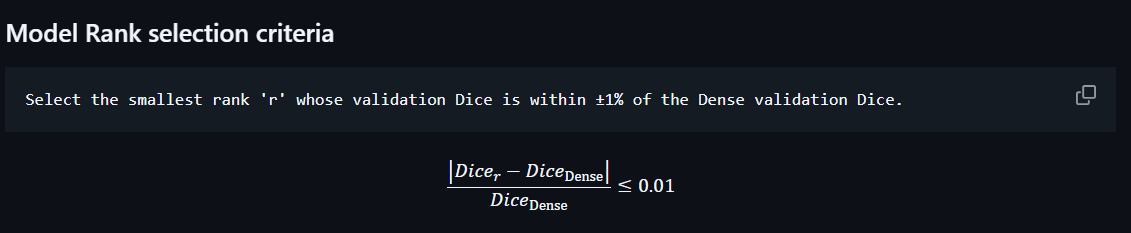
Then, for Rank-64, relative difference is -0.1292% which is less than 0.01 and for Rank-32, relative difference is -0.7047% which is also less than 0.01.

In that case, we need to use a tie handling case as,
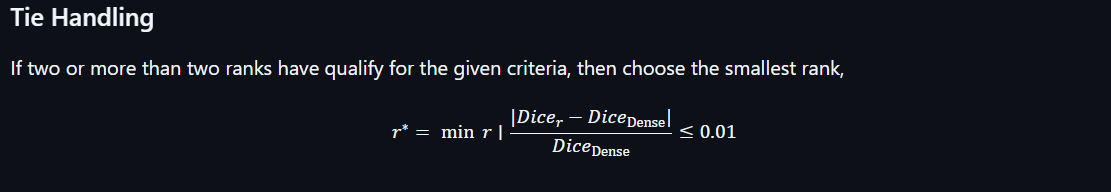
Where, we need to choose the minimum rank that satisfies, on in this case, the minimum rank that also satisfies the rank selection criteria is Rank-32. *Hence, we'll choose Rank-32 model for further experimentation*

## Dense Rank Model Testing

In [71]:
from src.models.downstream.segmentation import SegmentationProbing

dense_model = SegmentationProbing(
    model_backbone=model,
    is_baseline=False,
    feature_key="dense",
    feature_dim=768,
    num_classes=2,
    freeze_backbone=True,
    freeze_model=False,
    resize_output=(224, 224),
).to(device)

  # We'll be using Adam with weighted decay optimizer
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, dense_model.parameters()),
    lr=1e-3,weight_decay=1e-4,)
# We'll be using cross entropy loss
criterion = torch.nn.CrossEntropyLoss()

In [72]:
# Dense model running for seed 42, 123, 2026
import random

history = []

def train_dense_probe(seed, num_epochs=50):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # Best checkpoint in memory
    best_val_dice = -1.0
    best_epoch = -1
    best_state = None

    # Training
    for epoch in range(num_epochs):
        train_metrics = run_epoch(dense_model,probe_train_loader,optimizer=optimizer,
            criterion=criterion,device=device,)
        
        val_metrics = run_epoch(dense_model,probe_val_loader,optimizer=None,
            criterion=criterion,device=device,)

        history.append({
            "epoch": epoch + 1,
            "train_dice": train_metrics["gland_dice"],
            "train_miou": train_metrics["miou"],
            "val_dice": val_metrics["gland_dice"],
            "val_miou": val_metrics["miou"],
        })

        print(
            f"[Seed {seed}] "
            f"Epoch {epoch+1:02d}/{num_epochs} | "
            f"Train Dice: {train_metrics['gland_dice']:.4f} | "
            f"Val Dice: {val_metrics['gland_dice']:.4f}"
        )

        if val_metrics["gland_dice"] > best_val_dice:
            best_val_dice = val_metrics["gland_dice"]
            best_epoch = epoch + 1
            best_state = {
                k: v.detach().cpu().clone()
                for k, v in dense_model.state_dict().items()
            }



    # Restore best model
    dense_model.load_state_dict(best_state)
    dense_model.eval()

    # TestA
    testA_metrics = run_epoch(dense_model,testA_loader,optimizer=None,
        criterion=criterion,device=device,)

    # TestB
    testB_metrics = run_epoch(dense_model,testB_loader,optimizer=None,
        criterion=criterion,device=device,)
    
    return {
        "seed": seed,
        "best_epoch": best_epoch,
        "best_val_dice": best_val_dice,
        "testA": testA_metrics,
        "testB": testB_metrics,
        "history": history,
    }

In [73]:
dense_results = {}
for seed in [42, 123, 2026]:
    print("\n" + "=" * 70)
    print(f"STARTING DENSE PROBE — SEED {seed}")
    print("=" * 70)
    dense_results[seed] = train_dense_probe(seed=seed,num_epochs=50)


STARTING DENSE PROBE — SEED 42
[Seed 42] Epoch 01/50 | Train Dice: 0.7009 | Val Dice: 0.7920
[Seed 42] Epoch 02/50 | Train Dice: 0.7913 | Val Dice: 0.8068
[Seed 42] Epoch 03/50 | Train Dice: 0.8050 | Val Dice: 0.8168
[Seed 42] Epoch 04/50 | Train Dice: 0.8184 | Val Dice: 0.8137
[Seed 42] Epoch 05/50 | Train Dice: 0.8256 | Val Dice: 0.8351
[Seed 42] Epoch 06/50 | Train Dice: 0.8376 | Val Dice: 0.8371
[Seed 42] Epoch 07/50 | Train Dice: 0.8333 | Val Dice: 0.8389
[Seed 42] Epoch 08/50 | Train Dice: 0.8345 | Val Dice: 0.8385
[Seed 42] Epoch 09/50 | Train Dice: 0.8383 | Val Dice: 0.8414
[Seed 42] Epoch 10/50 | Train Dice: 0.8387 | Val Dice: 0.8341
[Seed 42] Epoch 11/50 | Train Dice: 0.8328 | Val Dice: 0.8278
[Seed 42] Epoch 12/50 | Train Dice: 0.8459 | Val Dice: 0.8295
[Seed 42] Epoch 13/50 | Train Dice: 0.8415 | Val Dice: 0.8338
[Seed 42] Epoch 14/50 | Train Dice: 0.8490 | Val Dice: 0.8347
[Seed 42] Epoch 15/50 | Train Dice: 0.8544 | Val Dice: 0.8392
[Seed 42] Epoch 16/50 | Train Dice: 0.

In [74]:
# Summary of Dense model result
def get_summary(results, split, metric):
    values = np.array([result[split][metric]for result in results.values()])
    return (values.mean(),values.std(ddof=1),)


for split in ["testA", "testB"]:
    print(f"\n===== {split.upper()} =====")
    for metric in ["gland_dice","gland_iou","miou",]:
        mean, std = get_summary( dense_results,split,metric,)
        print(f"{metric:15s} | {mean:.4f} ± {std:.4f}")


===== TESTA =====
gland_dice      | 0.8380 ± 0.0014
gland_iou       | 0.7211 ± 0.0021
miou            | 0.7176 ± 0.0050

===== TESTB =====
gland_dice      | 0.8363 ± 0.0008
gland_iou       | 0.7187 ± 0.0012
miou            | 0.6633 ± 0.0070


## Low Rank Model Testing

In [75]:
from src.models.downstream.segmentation import SegmentationProbing
lowrank_model = SegmentationProbing(
    model_backbone=model,
    is_baseline=False,
    feature_key="lowrank",
    feature_dim=768,
    num_classes=2,
    freeze_backbone=True,
    freeze_model=False,
    resize_output=(224, 224),
).to(device)


optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad,lowrank_model.parameters()),
    lr=1e-3,
    weight_decay=1e-4,)
criterion = torch.nn.CrossEntropyLoss()

In [76]:
import random

history=[]

def train_spatial_probe(seed, num_epochs=50):
    # Training randomness
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # Best checkpoint in memory
    best_val_dice = -1.0
    best_epoch = -1
    best_state = None
    
    # Training
    for epoch in range(num_epochs):
        train_metrics = run_epoch(lowrank_model,probe_train_loader,optimizer=optimizer,
            criterion=criterion,
            device=device,)
        
        val_metrics = run_epoch(lowrank_model,probe_val_loader,optimizer=None,
            criterion=criterion,
            device=device,)

        history.append({
            "epoch": epoch + 1,
            "train_dice": train_metrics["gland_dice"],
            "train_miou": train_metrics["miou"],
            "val_dice": val_metrics["gland_dice"],
            "val_miou": val_metrics["miou"],
        })

        print(
            f"[Seed {seed}] "
            f"Epoch {epoch+1:02d}/{num_epochs} | "
            f"Train Dice: {train_metrics['gland_dice']:.4f} | "
            f"Val Dice: {val_metrics['gland_dice']:.4f}"
        )

        if val_metrics["gland_dice"] > best_val_dice:
            best_val_dice = val_metrics["gland_dice"]
            best_epoch = epoch + 1
            best_state = {
                k: v.detach().cpu().clone()
                for k, v in lowrank_model.state_dict().items()
            }

    # Restore best model
    lowrank_model.load_state_dict(best_state)
    lowrank_model.eval()
    
    # TestA
    testA_metrics = run_epoch(lowrank_model,testA_loader,optimizer=None,
        criterion=criterion,device=device,)

    # TestB
    testB_metrics = run_epoch(lowrank_model,testB_loader,optimizer=None,
        criterion=criterion,device=device,)
    
    return {
        "seed": seed,
        "best_epoch": best_epoch,
        "best_val_dice": best_val_dice,
        "testA": testA_metrics,
        "testB": testB_metrics,
        "history": history,
    }

In [77]:
# Running for 3 SEEDS
lowrank_results = {}
for seed in [42, 123, 2026]:
    print("\n" + "=" * 70)
    print(f"STARTING LOWRANK PROBE — SEED {seed}")
    print("=" * 70)
    lowrank_results[seed] = train_spatial_probe(seed=seed,num_epochs=50,)


STARTING LOWRANK PROBE — SEED 42
[Seed 42] Epoch 01/50 | Train Dice: 0.5787 | Val Dice: 0.6735
[Seed 42] Epoch 02/50 | Train Dice: 0.6181 | Val Dice: 0.6970
[Seed 42] Epoch 03/50 | Train Dice: 0.6100 | Val Dice: 0.6813
[Seed 42] Epoch 04/50 | Train Dice: 0.6215 | Val Dice: 0.6908
[Seed 42] Epoch 05/50 | Train Dice: 0.6165 | Val Dice: 0.6907
[Seed 42] Epoch 06/50 | Train Dice: 0.6274 | Val Dice: 0.6663
[Seed 42] Epoch 07/50 | Train Dice: 0.6171 | Val Dice: 0.6565
[Seed 42] Epoch 08/50 | Train Dice: 0.6354 | Val Dice: 0.6445
[Seed 42] Epoch 09/50 | Train Dice: 0.6489 | Val Dice: 0.6312
[Seed 42] Epoch 10/50 | Train Dice: 0.6511 | Val Dice: 0.6103
[Seed 42] Epoch 11/50 | Train Dice: 0.6284 | Val Dice: 0.6084
[Seed 42] Epoch 12/50 | Train Dice: 0.6370 | Val Dice: 0.5855
[Seed 42] Epoch 13/50 | Train Dice: 0.6466 | Val Dice: 0.6558
[Seed 42] Epoch 14/50 | Train Dice: 0.6584 | Val Dice: 0.5636
[Seed 42] Epoch 15/50 | Train Dice: 0.6465 | Val Dice: 0.6175
[Seed 42] Epoch 16/50 | Train Dice: 

In [78]:
# Summary of Lowrank model result
def get_summary(results, split, metric):
    values = np.array([result[split][metric]for result in results.values()])
    return (values.mean(),values.std(ddof=1),)


for split in ["testA", "testB"]:
    print(f"\n===== {split.upper()} =====")
    for metric in ["gland_dice","gland_iou","miou",]:
        mean, std = get_summary( lowrank_results,split,metric,)
        print(f"{metric:15s} | {mean:.4f} ± {std:.4f}")


===== TESTA =====
gland_dice      | 0.6492 ± 0.0300
gland_iou       | 0.4811 ± 0.0333
miou            | 0.4138 ± 0.0476

===== TESTB =====
gland_dice      | 0.7014 ± 0.0143
gland_iou       | 0.5402 ± 0.0170
miou            | 0.4038 ± 0.0578


## Rank-32 Model Testing

In [79]:
import torch.nn as nn
rank32_backbone = RankTruncatedBackbone(model,rank=32)

rank32_model = SegmentationProbing(
    model_backbone=rank32_backbone,
    is_baseline=False,
    feature_key="dense",
    feature_dim=768,
    num_classes=2,
    freeze_backbone=True,
    freeze_model=False,
    resize_output=(224, 224),
).to(device)

optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad,rank32_model.parameters()),
    lr=1e-3,weight_decay=1e-4,)
criterion = nn.CrossEntropyLoss()

In [80]:
import random

history = []
def train_spatial_probe(seed, num_epochs=50):
    # Training randomness
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
    # Best checkpoint in memory
    best_val_dice = -1.0
    best_epoch = -1
    best_state = None

    # Training
    for epoch in range(num_epochs):
        train_metrics = run_epoch(rank32_model,probe_train_loader,optimizer=optimizer,
            criterion=criterion,device=device,)

        val_metrics = run_epoch(rank32_model,probe_val_loader,optimizer=None,
            criterion=criterion,device=device,)
        
        history.append({
            "epoch": epoch + 1,
            "train_dice": train_metrics["gland_dice"],
            "train_miou": train_metrics["miou"],
            "val_dice": val_metrics["gland_dice"],
            "val_miou": val_metrics["miou"],
        })

        print(
            f"[Seed {seed}] "
            f"Epoch {epoch+1:02d}/{num_epochs} | "
            f"Train Dice: {train_metrics['gland_dice']:.4f} | "
            f"Val Dice: {val_metrics['gland_dice']:.4f}"
        )

        if val_metrics["gland_dice"] > best_val_dice:
            best_val_dice = val_metrics["gland_dice"]
            best_epoch = epoch + 1
            best_state = {
                k: v.detach().cpu().clone()
                for k, v in rank32_model.state_dict().items()
            }

    
    # Restore best model
    rank32_model.load_state_dict(best_state)
    rank32_model.eval()
    
    # TestA
    testA_metrics = run_epoch(rank32_model,testA_loader,optimizer=None,criterion=criterion,
        device=device,)

    # TestB
    testB_metrics = run_epoch(rank32_model,testB_loader,optimizer=None,criterion=criterion,
        device=device,)
   
    return {
        "seed": seed,
        "best_epoch": best_epoch,
        "best_val_dice": best_val_dice,
        "testA": testA_metrics,
        "testB": testB_metrics,
        "history": history,
    }

In [81]:
rank32_results = {}

for seed in [42, 123, 2026]:
    print("\n" + "=" * 70)
    print(f"STARTING RANK-32 PROBE — SEED {seed}")
    print("=" * 70)
    rank32_results[seed] = train_spatial_probe(seed=seed,num_epochs=50,)


STARTING RANK-32 PROBE — SEED 42
[Seed 42] Epoch 01/50 | Train Dice: 0.7261 | Val Dice: 0.7844
[Seed 42] Epoch 02/50 | Train Dice: 0.8001 | Val Dice: 0.7946
[Seed 42] Epoch 03/50 | Train Dice: 0.8023 | Val Dice: 0.8062
[Seed 42] Epoch 04/50 | Train Dice: 0.8164 | Val Dice: 0.8019
[Seed 42] Epoch 05/50 | Train Dice: 0.8228 | Val Dice: 0.8248
[Seed 42] Epoch 06/50 | Train Dice: 0.8374 | Val Dice: 0.8267
[Seed 42] Epoch 07/50 | Train Dice: 0.8292 | Val Dice: 0.8237
[Seed 42] Epoch 08/50 | Train Dice: 0.8323 | Val Dice: 0.8280
[Seed 42] Epoch 09/50 | Train Dice: 0.8340 | Val Dice: 0.8292
[Seed 42] Epoch 10/50 | Train Dice: 0.8341 | Val Dice: 0.8274
[Seed 42] Epoch 11/50 | Train Dice: 0.8293 | Val Dice: 0.8192
[Seed 42] Epoch 12/50 | Train Dice: 0.8396 | Val Dice: 0.8227
[Seed 42] Epoch 13/50 | Train Dice: 0.8395 | Val Dice: 0.8265
[Seed 42] Epoch 14/50 | Train Dice: 0.8431 | Val Dice: 0.8262
[Seed 42] Epoch 15/50 | Train Dice: 0.8513 | Val Dice: 0.8321
[Seed 42] Epoch 16/50 | Train Dice: 

In [82]:
# Summary of Rank-32 model result
def get_summary(results, split, metric):
    values = np.array([result[split][metric]for result in results.values()])
    return (values.mean(),values.std(ddof=1),)


for split in ["testA", "testB"]:
    print(f"\n===== {split.upper()} =====")
    for metric in ["gland_dice","gland_iou","miou",]:
        mean, std = get_summary( rank32_results,split,metric,)
        print(f"{metric:15s} | {mean:.4f} ± {std:.4f}")


===== TESTA =====
gland_dice      | 0.8345 ± 0.0014
gland_iou       | 0.7159 ± 0.0021
miou            | 0.7169 ± 0.0017

===== TESTB =====
gland_dice      | 0.8197 ± 0.0023
gland_iou       | 0.6944 ± 0.0033
miou            | 0.6402 ± 0.0063


## Test Result Comparison

In [84]:
def get_summary(results, split, metric):
    values = np.array([result[split][metric]for result in results.values()])
    return (values.mean(),values.std(ddof=1),)
    
models = {
    "Dense": dense_results,
    "Low Rank": lowrank_results,
    "Rank-32": rank32_results,
}

splits = ["testA", "testB"]
metrics = ["gland_dice", "gland_iou", "miou"]

for model_name, results in models.items():
    print("\n" + "=" * 40)
    print(f"MODEL: {model_name}")
    print("=" * 40)
    
    for split in splits:
        print(f"\n===== {split.upper()} =====")
        for metric in metrics:
            mean, std = get_summary(results, split, metric)
            print(f"{metric:15s} | {mean:.4f} ± {std:.4f}")


MODEL: Dense

===== TESTA =====
gland_dice      | 0.8380 ± 0.0014
gland_iou       | 0.7211 ± 0.0021
miou            | 0.7176 ± 0.0050

===== TESTB =====
gland_dice      | 0.8363 ± 0.0008
gland_iou       | 0.7187 ± 0.0012
miou            | 0.6633 ± 0.0070

MODEL: Low Rank

===== TESTA =====
gland_dice      | 0.6492 ± 0.0300
gland_iou       | 0.4811 ± 0.0333
miou            | 0.4138 ± 0.0476

===== TESTB =====
gland_dice      | 0.7014 ± 0.0143
gland_iou       | 0.5402 ± 0.0170
miou            | 0.4038 ± 0.0578

MODEL: Rank-32

===== TESTA =====
gland_dice      | 0.8345 ± 0.0014
gland_iou       | 0.7159 ± 0.0021
miou            | 0.7169 ± 0.0017

===== TESTB =====
gland_dice      | 0.8197 ± 0.0023
gland_iou       | 0.6944 ± 0.0033
miou            | 0.6402 ± 0.0063


Held-out evaluation of the validation-selected Rank-32 model shows near-Dense performance on Test A, with only a 0.42% reduction in gland Dice and 0.10% reduction in mIoU. On Test B, however, Rank-32 exhibits a larger degradation, with gland Dice, gland IoU, and mIoU decreasing by approximately 1.98%, 3.38%, and 3.48%, respectively, relative to Dense.

And, we also find that, for Dense Rank Model,
1. Feature Rank = 196
2. Effective Rank = 119.89

For Rank-32 Model, 
1. Feature Rank = 32
2. Effective Rank = 25.97

So, that's a total of 78.38% rank compression in effective rank scale while giving much close to performance relative to Dense Model.
   